Dataset loaded successfully
Shape: (45, 36)


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,event_date,description
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN,NaN,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,NaN,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,NaN,NaN



Record Type Summary


record_type
observation    31
event          11
target          3
Name: count, dtype: int64

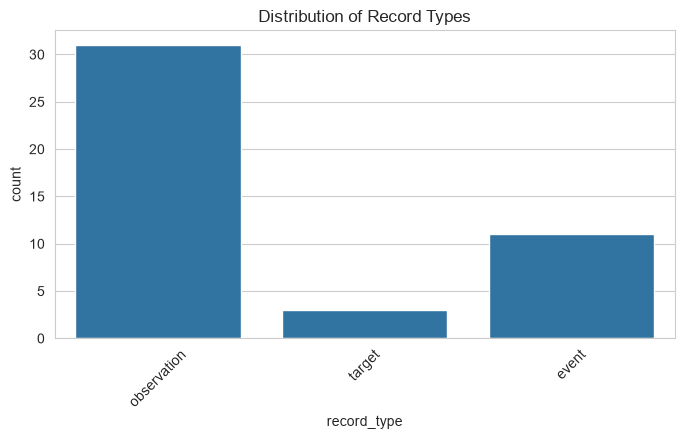

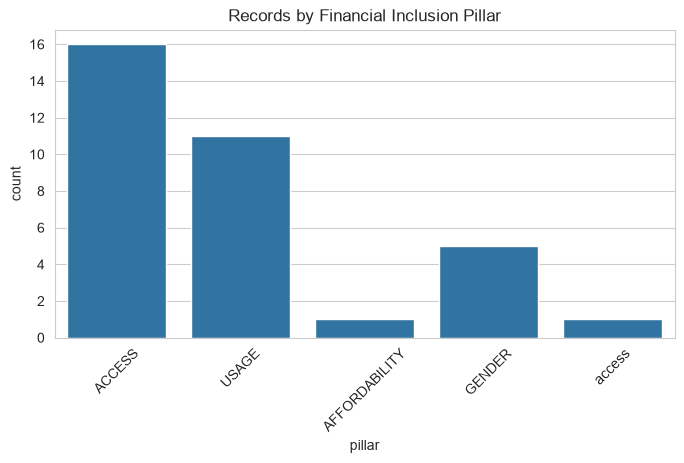

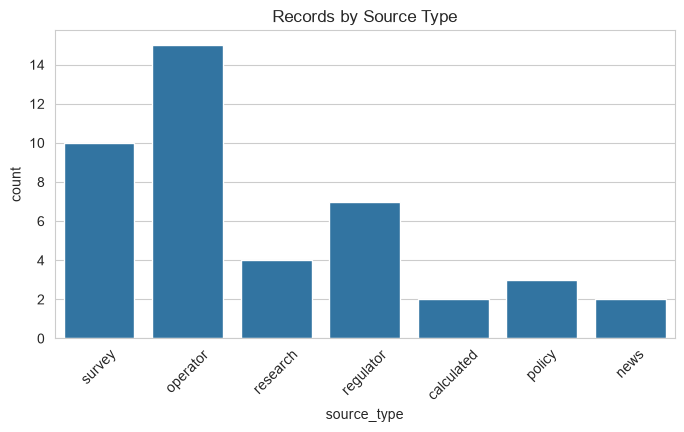

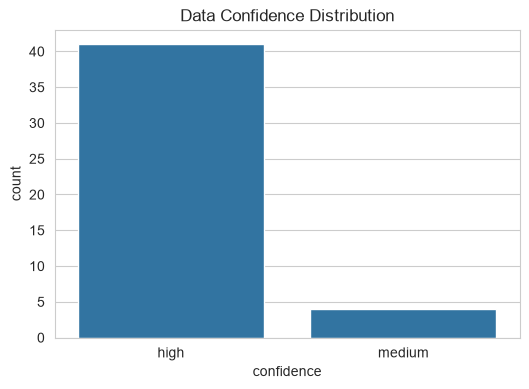


Missing Values


impact_magnitude       45
lag_months             45
impact_estimate        45
evidence_basis         45
region                 45
relationship_type      45
impact_direction       45
related_indicator      45
description            44
event_date             44
notes                  43
period_end             35
value_text             35
period_start           35
category               34
collection_date        33
unit                   12
source_url             12
indicator_direction    12
value_numeric          11
pillar                 11
original_text          10
year                    2
record_id               2
comparable_country      2
fiscal_year             2
value_type              2
observation_date        2
location                2
gender                  2
source_type             2
indicator_code          1
indicator               1
record_type             0
source_name             0
confidence              0
collected_by            0
dtype: int64

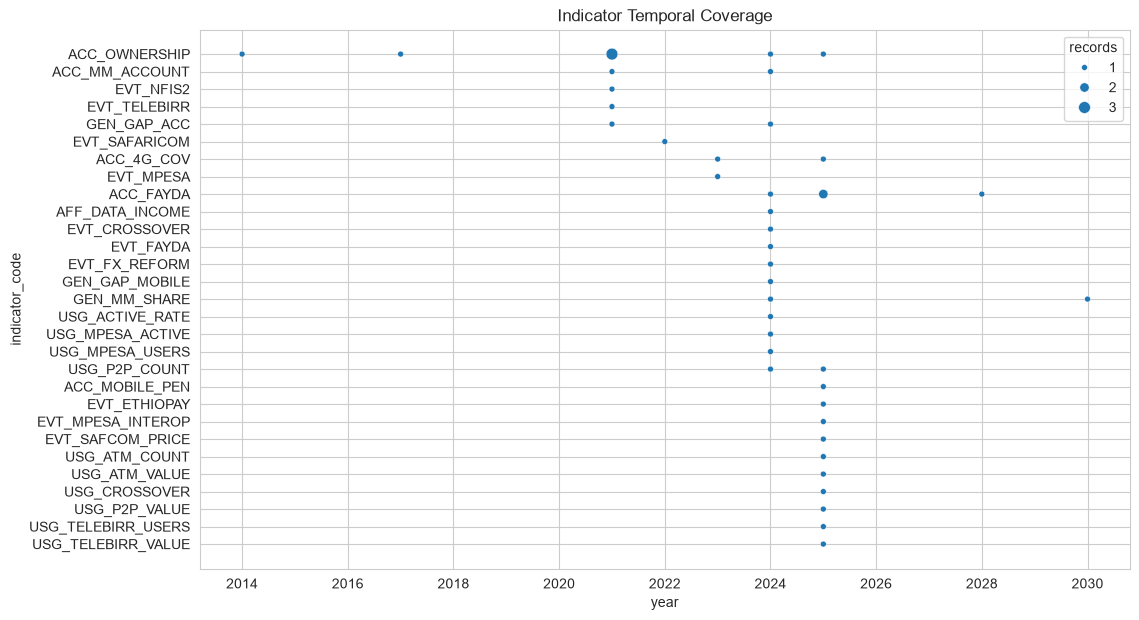


Indicators with lowest coverage


indicator_code
ACC_MOBILE_PEN       1
EVT_ETHIOPAY         1
EVT_CROSSOVER        1
AFF_DATA_INCOME      1
EVT_MPESA_INTEROP    1
EVT_MPESA            1
EVT_FX_REFORM        1
EVT_FAYDA            1
EVT_NFIS2            1
EVT_SAFARICOM        1
dtype: int64

Access records: 3


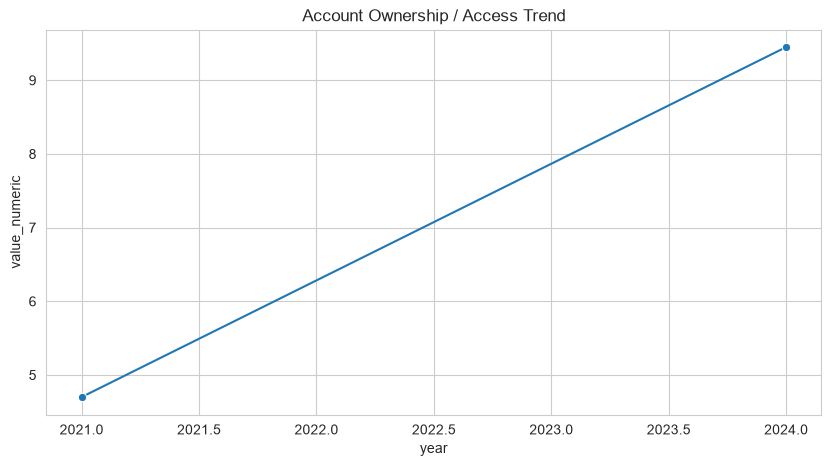

,year,value_numeric,growth_rate
6,2021.0,4.70,NaN
7,2024.0,9.45,101.063830
43,NaN,46.00,386.772487


Mobile money records: 3


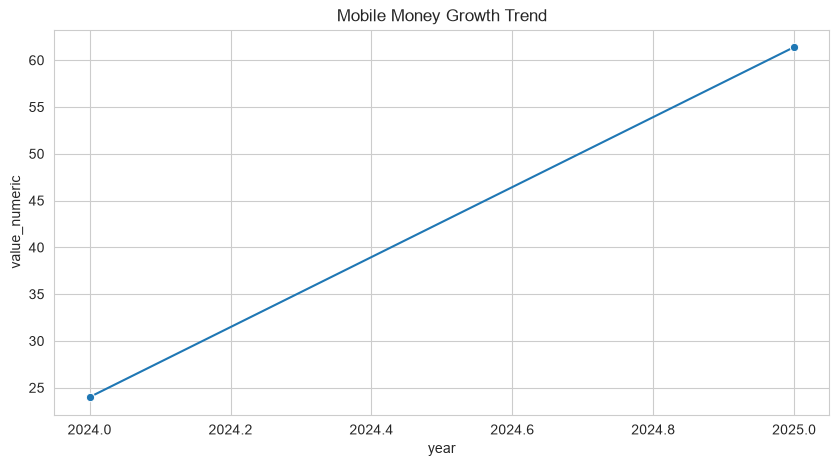

Infrastructure records: 0
Total events: 11


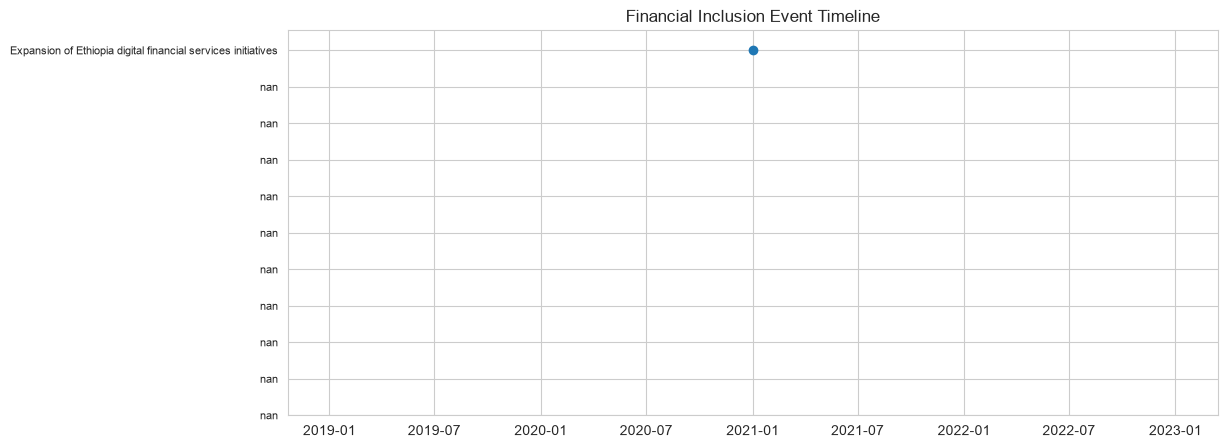

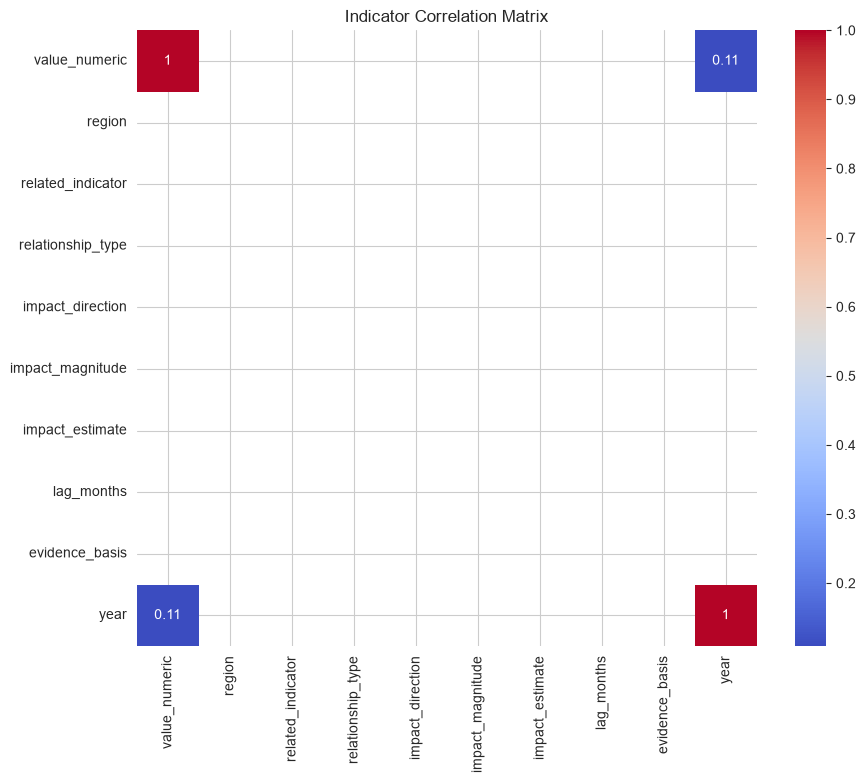


TASK 2 EDA COMPLETED SUCCESSFULLY

Created:
✓ Dataset analysis
✓ Data quality analysis
✓ Indicator coverage
✓ Access analysis
✓ Mobile money analysis
✓ Infrastructure analysis
✓ Event timeline
✓ Correlation analysis
✓ Saved visualizations

Next:
Write Task 2 insights report



In [8]:
# ============================================================
# TASK 2: EXPLORATORY DATA ANALYSIS (EDA)
# Ethiopia Financial Inclusion Forecast Project
# ============================================================


# ============================
# 1. Import Libraries
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


sns.set_style("whitegrid")


# ============================
# 2. Load Dataset
# ============================

DATA_PATH = "../data/processed/ethiopia_fi_enriched_data.csv"

FIGURE_PATH = "../reports/figures/"

os.makedirs(
    FIGURE_PATH,
    exist_ok=True
)


data = pd.read_csv(
    DATA_PATH
)


print("Dataset loaded successfully")
print("Shape:", data.shape)


display(data.head())



# ============================
# 3. Data Preparation
# ============================


# Convert dates

date_columns = [
    "observation_date",
    "event_date",
    "target_date"
]


for col in date_columns:

    if col in data.columns:

        data[col] = pd.to_datetime(
            data[col],
            errors="coerce"
        )



# Create year column

if "observation_date" in data.columns:

    data["year"] = (
        data["observation_date"]
        .dt.year
    )



# ============================
# 4. Dataset Overview
# ============================


print("\nRecord Type Summary")

display(
    data["record_type"]
    .value_counts()
)



plt.figure(figsize=(8,4))

sns.countplot(
    data=data,
    x="record_type"
)

plt.title(
    "Distribution of Record Types"
)

plt.xticks(rotation=45)

plt.savefig(
    FIGURE_PATH+"record_type_distribution.png",
    bbox_inches="tight"
)

plt.show()



# Pillar analysis

if "pillar" in data.columns:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=data,
        x="pillar"
    )

    plt.title(
        "Records by Financial Inclusion Pillar"
    )

    plt.xticks(rotation=45)

    plt.savefig(
        FIGURE_PATH+"pillar_distribution.png",
        bbox_inches="tight"
    )

    plt.show()



# Source analysis


if "source_type" in data.columns:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=data,
        x="source_type"
    )

    plt.title(
        "Records by Source Type"
    )

    plt.xticks(rotation=45)

    plt.savefig(
        FIGURE_PATH+"source_distribution.png",
        bbox_inches="tight"
    )

    plt.show()



# ============================
# 5. Data Quality Analysis
# ============================


if "confidence" in data.columns:


    plt.figure(figsize=(6,4))

    sns.countplot(
        data=data,
        x="confidence"
    )


    plt.title(
        "Data Confidence Distribution"
    )


    plt.savefig(
        FIGURE_PATH+"confidence_distribution.png",
        bbox_inches="tight"
    )


    plt.show()



print("\nMissing Values")

display(
    data.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)



# ============================
# 6. Temporal Coverage
# ============================


if "indicator_code" in data.columns:


    coverage = (
        data
        .groupby(
            [
                "year",
                "indicator_code"
            ]
        )
        .size()
        .reset_index(
            name="records"
        )
    )


    plt.figure(figsize=(12,7))


    sns.scatterplot(
        data=coverage,
        x="year",
        y="indicator_code",
        size="records"
    )


    plt.title(
        "Indicator Temporal Coverage"
    )


    plt.savefig(
        FIGURE_PATH+"indicator_temporal_coverage.png",
        bbox_inches="tight"
    )


    plt.show()



# Sparse indicators

print("\nIndicators with lowest coverage")

display(
    data.groupby(
        "indicator_code"
    )
    .size()
    .sort_values()
    .head(10)
)



# ============================
# 7. Access Analysis
# ============================


access = data[
    data["indicator_code"]
    .astype(str)
    .str.contains(
        "account|access",
        case=False,
        na=False
    )
]


print(
    "Access records:",
    len(access)
)



if len(access)>0:


    plt.figure(figsize=(10,5))


    sns.lineplot(
        data=access,
        x="year",
        y="value_numeric",
        marker="o"
    )


    plt.title(
        "Account Ownership / Access Trend"
    )


    plt.savefig(
        FIGURE_PATH+"account_access_trend.png",
        bbox_inches="tight"
    )


    plt.show()



    access["growth_rate"] = (
        access["value_numeric"]
        .pct_change()*100
    )


    display(
        access[
            [
            "year",
            "value_numeric",
            "growth_rate"
            ]
        ]
    )



# ============================
# 8. Mobile Money Analysis
# ============================


mobile = data[
    data["indicator_code"]
    .astype(str)
    .str.contains(
        "mobile|money",
        case=False,
        na=False
    )
]



print(
    "Mobile money records:",
    len(mobile)
)



if len(mobile)>0:


    plt.figure(figsize=(10,5))


    sns.lineplot(
        data=mobile,
        x="year",
        y="value_numeric",
        marker="o"
    )


    plt.title(
        "Mobile Money Growth Trend"
    )


    plt.savefig(
        FIGURE_PATH+"mobile_money_trend.png",
        bbox_inches="tight"
    )


    plt.show()



# ============================
# 9. Infrastructure Analysis
# ============================


if "pillar" in data.columns:


    infrastructure = data[
        data["pillar"]
        .astype(str)
        .str.contains(
            "infrastructure",
            case=False
        )
    ]


    print(
        "Infrastructure records:",
        len(infrastructure)
    )


    if len(infrastructure)>0:


        sns.lineplot(
            data=infrastructure,
            x="year",
            y="value_numeric",
            hue="indicator_code"
        )


        plt.title(
            "Infrastructure Indicators Trend"
        )


        plt.savefig(
            FIGURE_PATH+"infrastructure_trends.png",
            bbox_inches="tight"
        )


        plt.show()



# ============================
# 10. Event Timeline
# ============================


events = data[
    data["record_type"]
    =="event"
]


print(
    "Total events:",
    len(events)
)



if len(events)>0:


    plt.figure(figsize=(12,5))


    plt.scatter(
        events["event_date"],
        range(len(events))
    )


    plt.yticks(
        range(len(events)),
        events["description"],
        fontsize=8
    )


    plt.title(
        "Financial Inclusion Event Timeline"
    )


    plt.savefig(
        FIGURE_PATH+"event_timeline.png",
        bbox_inches="tight"
    )


    plt.show()



# ============================
# 11. Correlation Analysis
# ============================


numeric_data = data.select_dtypes(
    include=np.number
)


if numeric_data.shape[1]>1:


    correlation = (
        numeric_data
        .corr()
    )


    plt.figure(figsize=(10,8))


    sns.heatmap(
        correlation,
        annot=True,
        cmap="coolwarm"
    )


    plt.title(
        "Indicator Correlation Matrix"
    )


    plt.savefig(
        FIGURE_PATH+"correlation_heatmap.png",
        bbox_inches="tight"
    )


    plt.show()



# ============================
# 12. Save EDA Summary
# ============================


summary = {

"Total Records":len(data),

"Total Indicators":
data["indicator_code"].nunique()
if "indicator_code" in data.columns
else 0,

"Total Events":
len(events),

"Missing Values":
data.isnull().sum().sum()

}



summary_df = pd.DataFrame(
    summary.items(),
    columns=[
        "Metric",
        "Value"
    ]
)


summary_df.to_csv(
    "../reports/task2_eda_summary.csv",
    index=False
)



print("""
=====================================
TASK 2 EDA COMPLETED SUCCESSFULLY

Created:
✓ Dataset analysis
✓ Data quality analysis
✓ Indicator coverage
✓ Access analysis
✓ Mobile money analysis
✓ Infrastructure analysis
✓ Event timeline
✓ Correlation analysis
✓ Saved visualizations

Next:
Write Task 2 insights report
=====================================
""")

DATASET SHAPE
(45, 36)


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,event_date,description
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN,NaN,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,NaN,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,NaN,NaN



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            43 non-null     str           
 1   record_type          45 non-null     str           
 2   category             11 non-null     str           
 3   pillar               34 non-null     str           
 4   indicator            44 non-null     str           
 5   indicator_code       44 non-null     str           
 6   indicator_direction  33 non-null     str           
 7   value_numeric        34 non-null     float64       
 8   value_text           10 non-null     str           
 9   value_type           43 non-null     str           
 10  unit                 33 non-null     str           
 11  observation_date     43 non-null     datetime64[us]
 12  period_start         10 non-null     datetime64[us]
 13  period_end           10 non

C:\Users\Test\AppData\Local\Temp\ipykernel_15484\329809575.py:49: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], errors="coerce")


None

...

record_type
observation    31
event          11
target          3
Name: count, dtype: int64


Pillars


pillar
ACCESS           16
USAGE            11
GENDER            5
AFFORDABILITY     1
access            1
Name: count, dtype: int64


Source Types


source_type
operator      15
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64

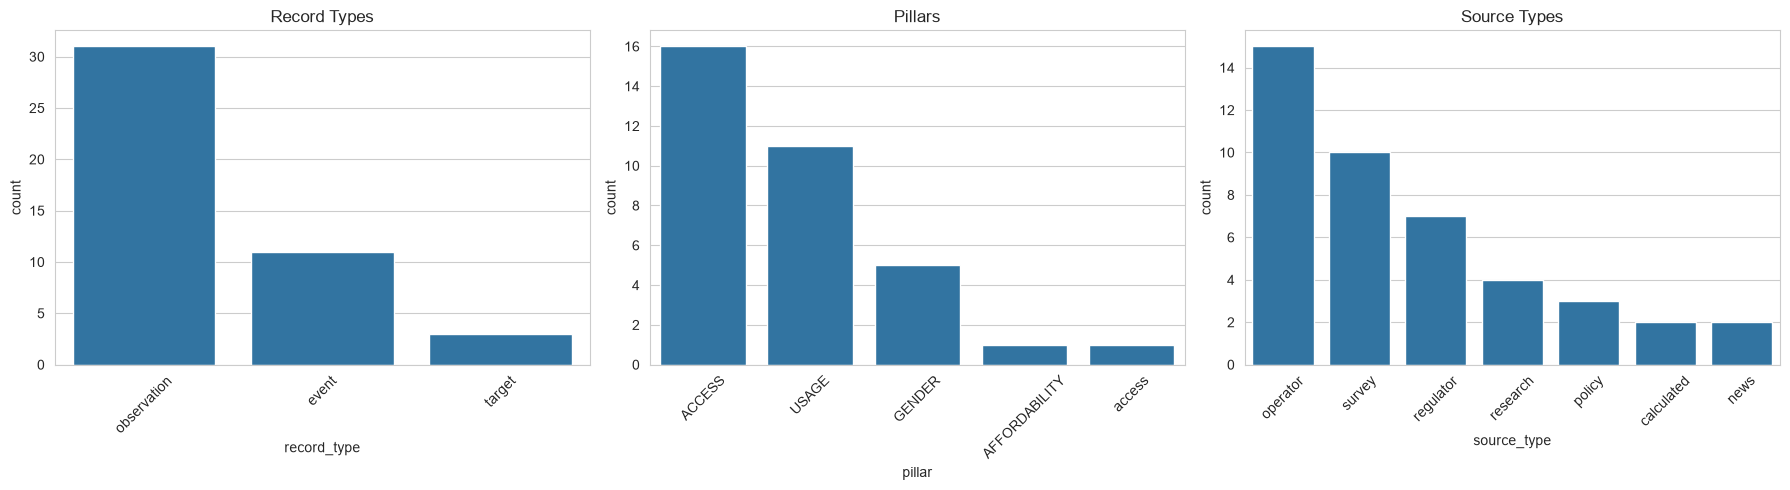


Missing Values


,Column,Missing
0,impact_magnitude,45
1,lag_months,45
2,impact_estimate,45
3,evidence_basis,45
4,region,45
5,relationship_type,45
6,impact_direction,45
7,related_indicator,45
8,description,44
9,event_date,44


C:\Users\Test\AppData\Local\Temp\ipykernel_15484\329809575.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing.head(15),


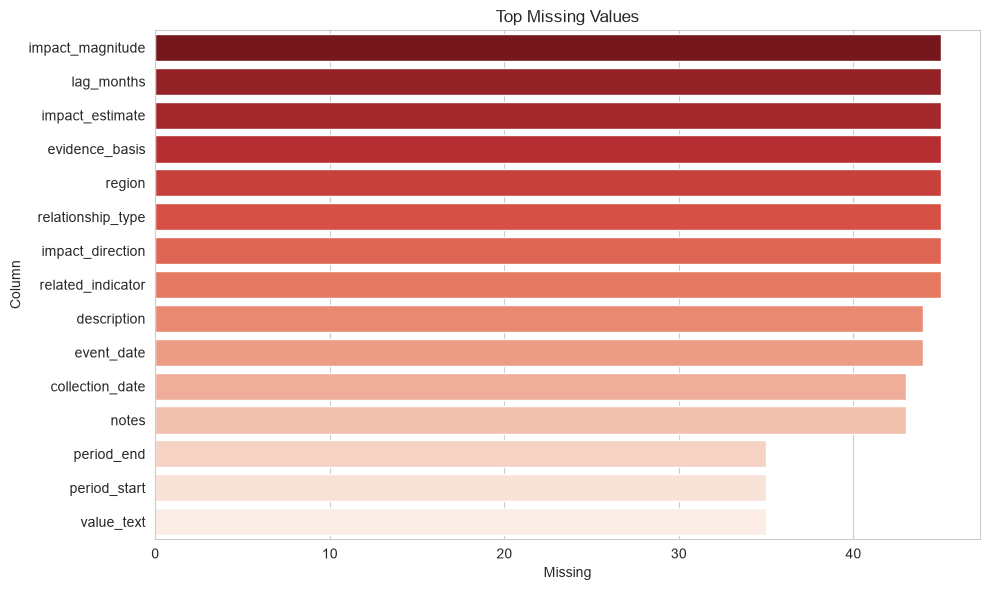

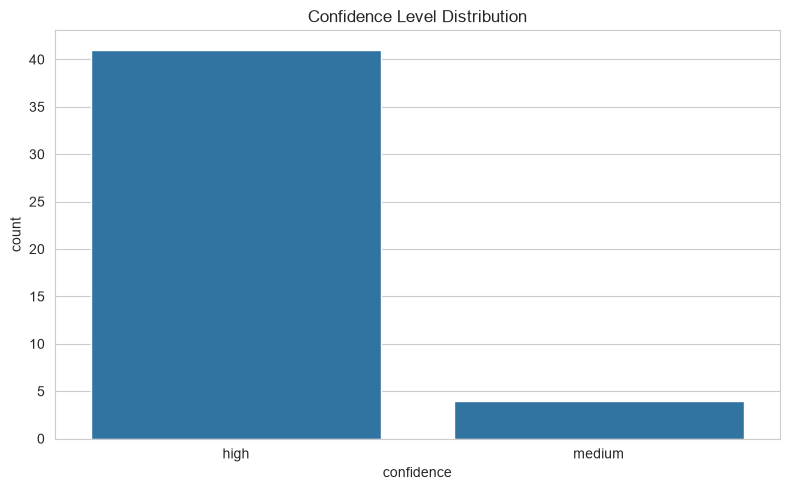

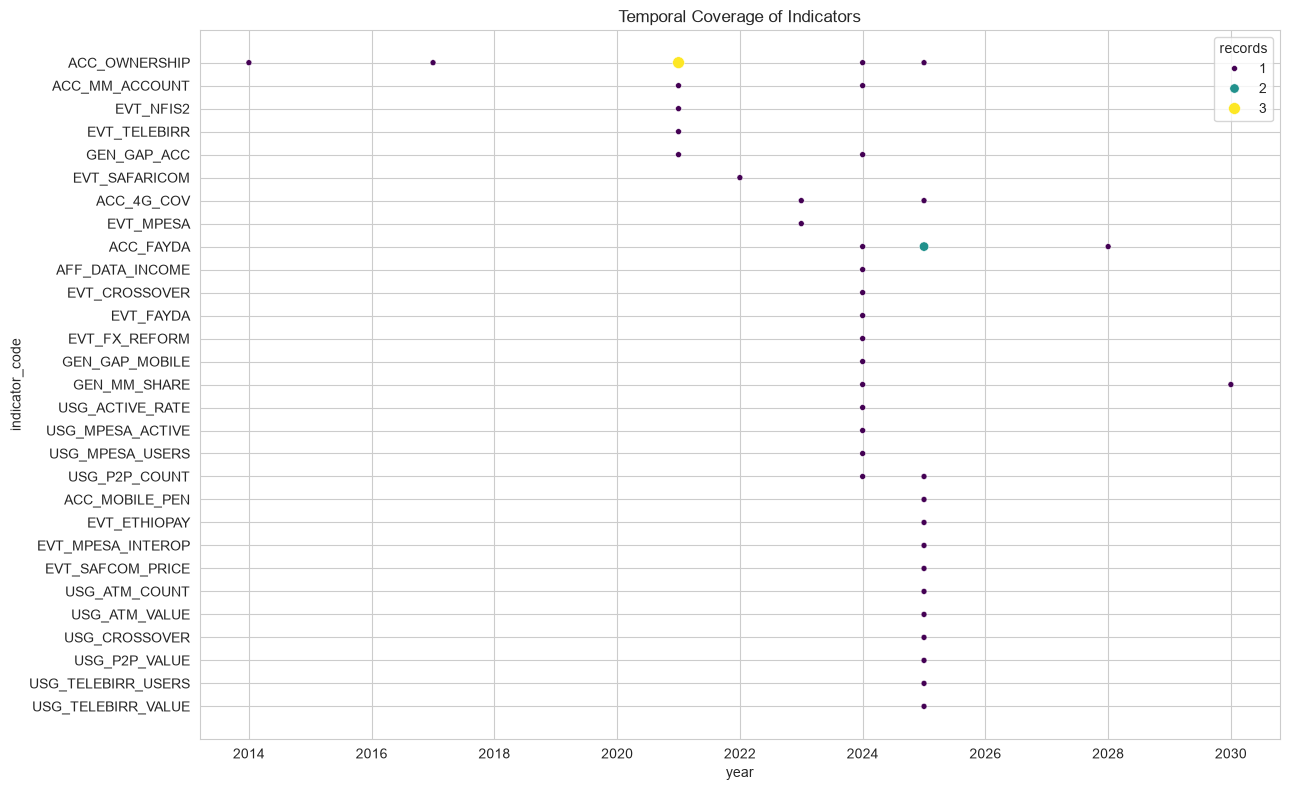

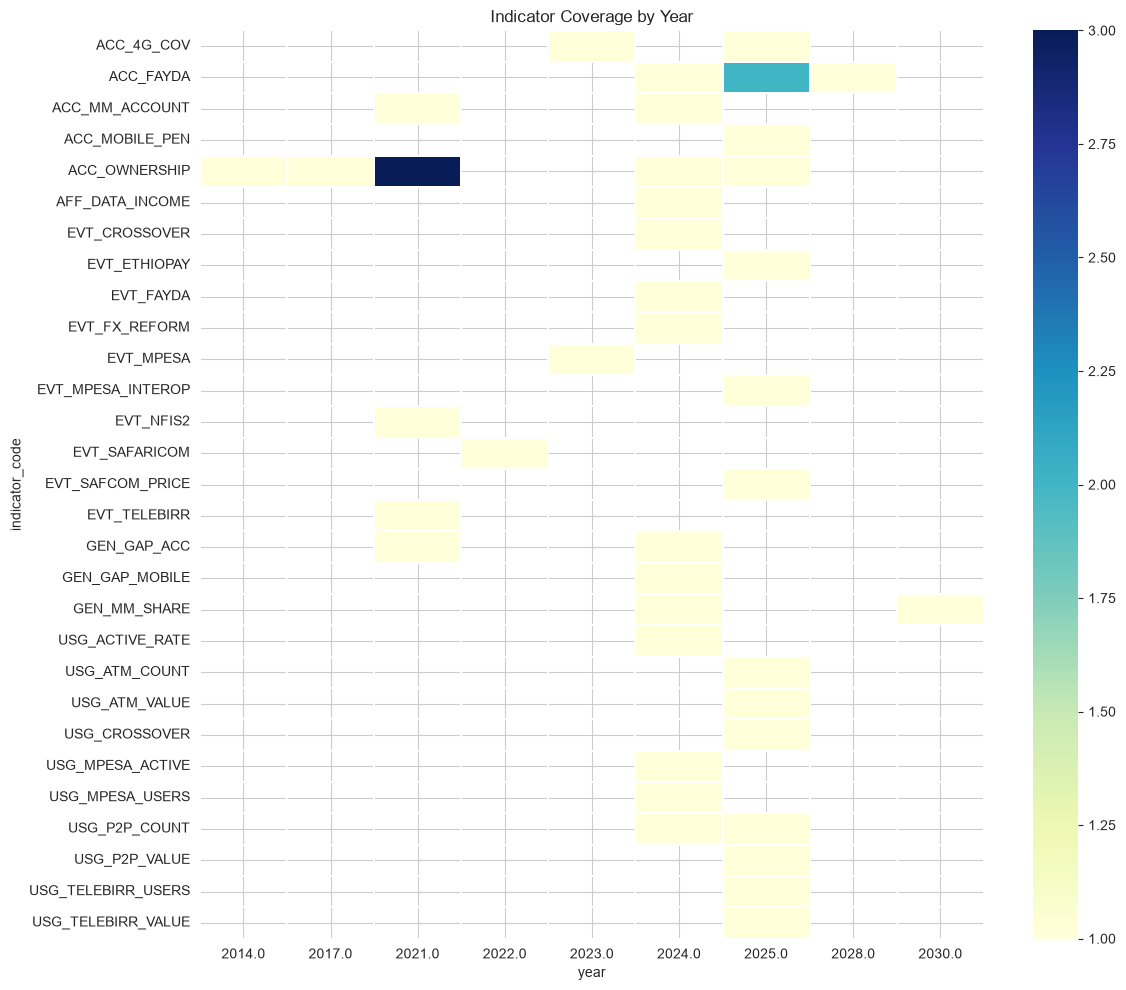


Indicators with Lowest Coverage


indicator_code
ACC_MOBILE_PEN         1
EVT_ETHIOPAY           1
EVT_CROSSOVER          1
AFF_DATA_INCOME        1
EVT_MPESA_INTEROP      1
EVT_MPESA              1
EVT_FX_REFORM          1
EVT_FAYDA              1
EVT_NFIS2              1
EVT_SAFARICOM          1
EVT_SAFCOM_PRICE       1
EVT_TELEBIRR           1
USG_ACTIVE_RATE        1
USG_ATM_COUNT          1
MOBILE_MONEY_ACCESS    1
dtype: int64

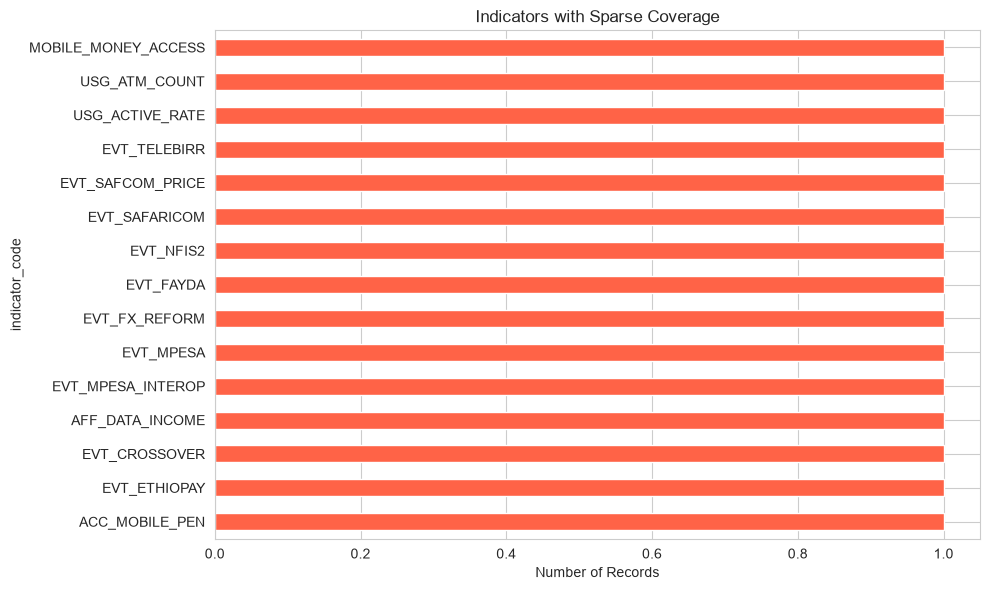

PART 1 COMPLETED


In [9]:
# ============================================================
# TASK 2 - EXPLORATORY DATA ANALYSIS (PART 1)
# Ethiopia Financial Inclusion Forecast Project
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# ------------------------------------------------------------
# Load Data
# ------------------------------------------------------------

DATA_PATH = "../data/processed/ethiopia_fi_enriched_data.csv"
REPORT_PATH = "../reports"
FIGURE_PATH = "../reports/figures"

os.makedirs(REPORT_PATH, exist_ok=True)
os.makedirs(FIGURE_PATH, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print("="*60)
print("DATASET SHAPE")
print(df.shape)
print("="*60)

display(df.head())

# ------------------------------------------------------------
# Data Preparation
# ------------------------------------------------------------

date_cols = [
    "observation_date",
    "period_start",
    "period_end",
    "collection_date",
    "event_date"
]

for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

df["year"] = df["observation_date"].dt.year

# ------------------------------------------------------------
# Dataset Information
# ------------------------------------------------------------

print("\nDataset Information")
display(df.info())

print("\nSummary Statistics")
display(df.describe(include="all"))

# ------------------------------------------------------------
# Dataset Overview
# ------------------------------------------------------------

print("\nRecord Types")
display(df["record_type"].value_counts())

print("\nPillars")
display(df["pillar"].value_counts())

print("\nSource Types")
display(df["source_type"].value_counts())

fig, ax = plt.subplots(1,3, figsize=(18,5))

sns.countplot(data=df,
              x="record_type",
              order=df["record_type"].value_counts().index,
              ax=ax[0])

ax[0].set_title("Record Types")
ax[0].tick_params(axis="x", rotation=45)

sns.countplot(data=df,
              x="pillar",
              order=df["pillar"].value_counts().index,
              ax=ax[1])

ax[1].set_title("Pillars")
ax[1].tick_params(axis="x", rotation=45)

sns.countplot(data=df,
              x="source_type",
              order=df["source_type"].value_counts().index,
              ax=ax[2])

ax[2].set_title("Source Types")
ax[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{FIGURE_PATH}/dataset_overview.png")
plt.show()

# ------------------------------------------------------------
# Data Quality Assessment
# ------------------------------------------------------------

print("\nMissing Values")

missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

missing.columns = ["Column","Missing"]

display(missing)

plt.figure(figsize=(10,6))

sns.barplot(data=missing.head(15),
            x="Missing",
            y="Column",
            palette="Reds_r")

plt.title("Top Missing Values")
plt.tight_layout()
plt.savefig(f"{FIGURE_PATH}/missing_values.png")
plt.show()

# ------------------------------------------------------------
# Confidence Distribution
# ------------------------------------------------------------

if "confidence" in df.columns:

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x="confidence",
        order=df["confidence"].value_counts().index
    )

    plt.title("Confidence Level Distribution")

    plt.tight_layout()

    plt.savefig(f"{FIGURE_PATH}/confidence_distribution.png")

    plt.show()

# ------------------------------------------------------------
# Temporal Coverage
# ------------------------------------------------------------

coverage = (
    df.groupby(["year","indicator_code"])
      .size()
      .reset_index(name="records")
)

plt.figure(figsize=(13,8))

sns.scatterplot(
    data=coverage,
    x="year",
    y="indicator_code",
    size="records",
    hue="records",
    palette="viridis"
)

plt.title("Temporal Coverage of Indicators")
plt.tight_layout()

plt.savefig(f"{FIGURE_PATH}/temporal_coverage.png")

plt.show()

# ------------------------------------------------------------
# Coverage Heatmap
# ------------------------------------------------------------

heat = (
    df.pivot_table(
        index="indicator_code",
        columns="year",
        values="record_id",
        aggfunc="count"
    )
)

plt.figure(figsize=(12,10))

sns.heatmap(
    heat,
    cmap="YlGnBu",
    linewidths=.3
)

plt.title("Indicator Coverage by Year")

plt.tight_layout()

plt.savefig(f"{FIGURE_PATH}/coverage_heatmap.png")

plt.show()

# ------------------------------------------------------------
# Sparse Indicators
# ------------------------------------------------------------

indicator_counts = (
    df.groupby("indicator_code")
      .size()
      .sort_values()
)

print("\nIndicators with Lowest Coverage")

display(indicator_counts.head(15))

plt.figure(figsize=(10,6))

indicator_counts.head(15).plot(
    kind="barh",
    color="tomato"
)

plt.title("Indicators with Sparse Coverage")
plt.xlabel("Number of Records")

plt.tight_layout()

plt.savefig(f"{FIGURE_PATH}/sparse_indicators.png")

plt.show()

print("="*60)
print("PART 1 COMPLETED")
print("="*60)


ACCESS ANALYSIS
Access Records: 14


,year,indicator,gender,location,value_numeric
0,2014.0,Account Ownership Rate,all,national,22.0
1,2017.0,Account Ownership Rate,all,national,35.0
2,2021.0,Account Ownership Rate,all,national,46.0
3,2021.0,Account Ownership Rate,male,national,56.0
4,2021.0,Account Ownership Rate,female,national,36.0


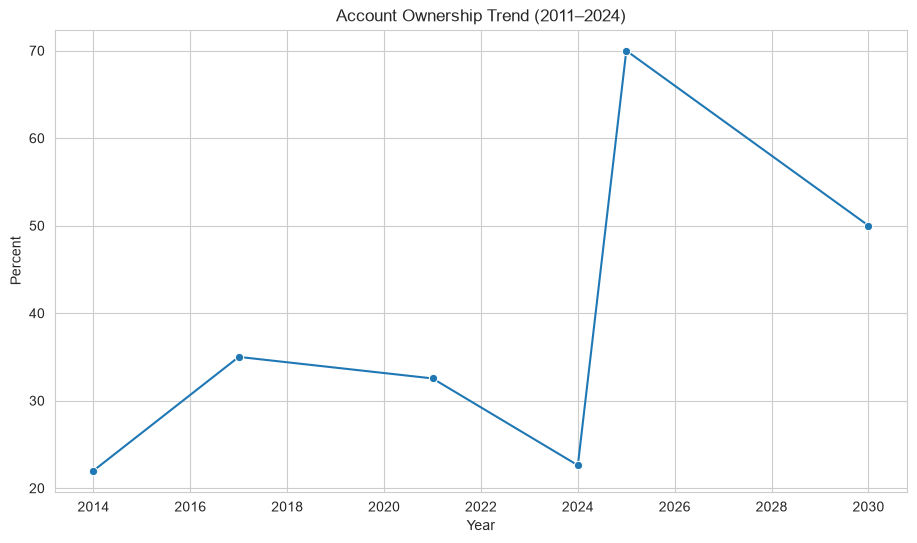


Growth Between Survey Years


,year,value_numeric,Growth_pp,Growth_percent
0,2014.0,22.0000,NaN,NaN
1,2017.0,35.0000,13.0000,59.090909
2,2021.0,32.5400,-2.4600,-7.028571
3,2024.0,22.6125,-9.9275,-30.508605


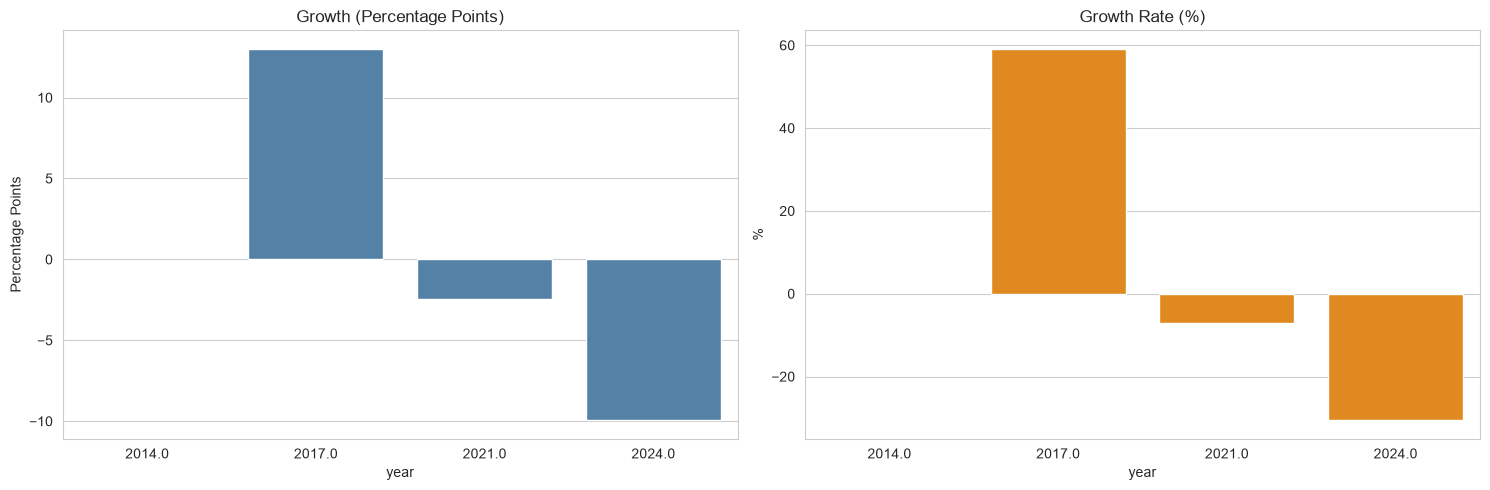


Gender Gap Analysis


,year,gender,value_numeric
0,2014.0,all,22.000000
1,2017.0,all,35.000000
2,2021.0,all,23.566667
3,2021.0,female,36.000000
4,2021.0,male,56.000000
5,2024.0,all,25.483333
6,2024.0,female,14.000000
7,2025.0,all,70.000000
8,2030.0,female,50.000000


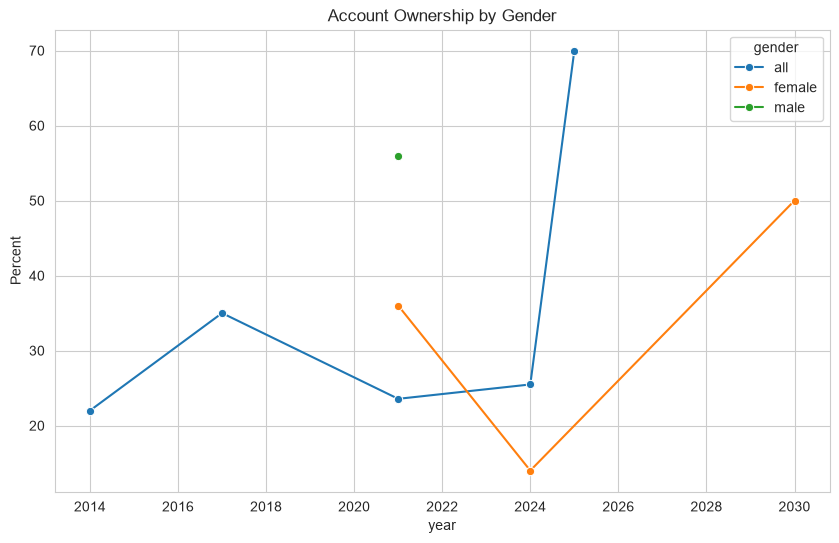


Urban vs Rural Analysis


,year,location,value_numeric
0,2014.0,national,22.0000
1,2017.0,national,35.0000
2,2021.0,national,32.5400
3,2024.0,national,22.6125
4,2025.0,national,70.0000
5,2030.0,national,50.0000


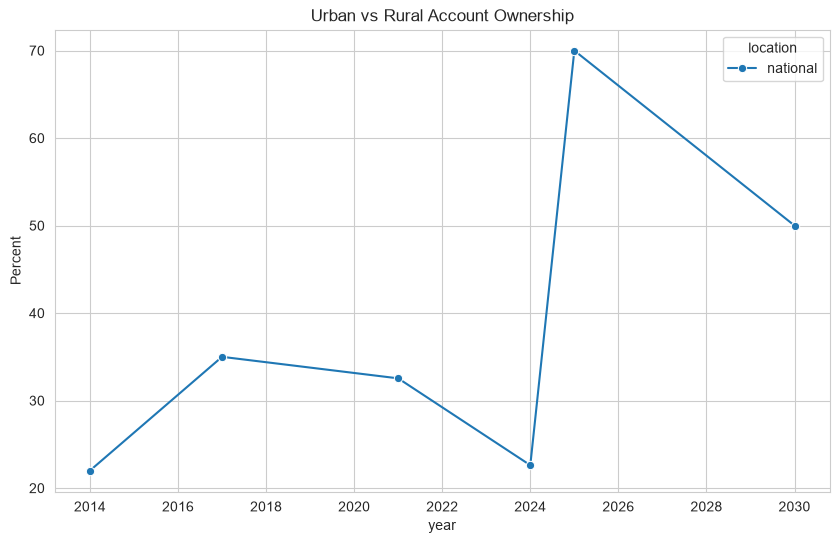


2021–2024 Slowdown


,year,value_numeric,Growth_pp,Growth_percent
2,2021.0,32.5400,-2.4600,-7.028571
3,2024.0,22.6125,-9.9275,-30.508605


Account ownership increased by -9.93 percentage points between 2021 and 2024.


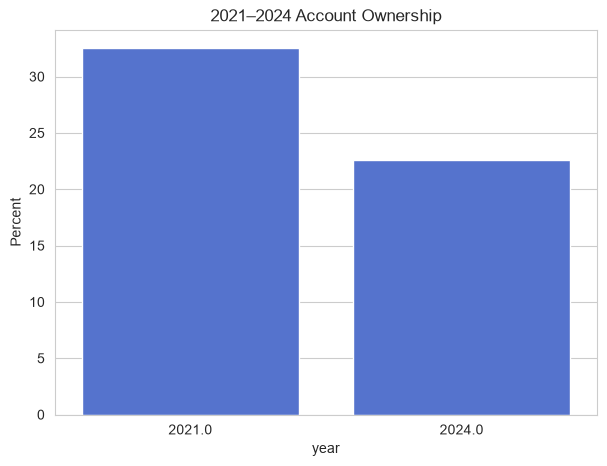


Possible explanations:
• Market approaching saturation.
• Many mobile money registrations remain inactive.
• Multiple SIM registrations inflate account numbers.
• Rural and low-income populations remain underserved.
• Financial literacy and digital access barriers persist.
• Infrastructure expansion does not immediately translate into active usage.

PART 2 COMPLETED


In [10]:
# ============================================================
# PART 2 - ACCESS ANALYSIS
# ============================================================

print("\n" + "="*70)
print("ACCESS ANALYSIS")
print("="*70)

# ------------------------------------------------------------
# Account Ownership Indicators
# ------------------------------------------------------------

access = df[
    df["indicator"].astype(str).str.contains(
        "account", case=False, na=False
    )
].copy()

access = access.sort_values("year")

print("Access Records:", len(access))

display(
    access[
        [
            "year",
            "indicator",
            "gender",
            "location",
            "value_numeric"
        ]
    ].head()
)

# ------------------------------------------------------------
# Ethiopia Account Ownership Trend
# ------------------------------------------------------------

if len(access) > 0:

    plt.figure(figsize=(11,6))

    sns.lineplot(
        data=access,
        x="year",
        y="value_numeric",
        marker="o",
        estimator="mean",
        errorbar=None
    )

    plt.title("Account Ownership Trend (2011–2024)")
    plt.xlabel("Year")
    plt.ylabel("Percent")

    plt.grid(True)

    plt.savefig(
        f"{FIGURE_PATH}/account_ownership_trend.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ------------------------------------------------------------
# Growth Between Survey Years
# ------------------------------------------------------------

survey_years = [2011, 2014, 2017, 2021, 2024]

growth = (
    access[
        access["year"].isin(survey_years)
    ]
    .groupby("year")["value_numeric"]
    .mean()
    .reset_index()
)

growth["Growth_pp"] = growth["value_numeric"].diff()

growth["Growth_percent"] = (
    growth["value_numeric"].pct_change() * 100
)

print("\nGrowth Between Survey Years")

display(growth)

fig, ax = plt.subplots(1,2, figsize=(15,5))

sns.barplot(
    data=growth,
    x="year",
    y="Growth_pp",
    color="steelblue",
    ax=ax[0]
)

ax[0].set_title("Growth (Percentage Points)")
ax[0].set_ylabel("Percentage Points")

sns.barplot(
    data=growth,
    x="year",
    y="Growth_percent",
    color="darkorange",
    ax=ax[1]
)

ax[1].set_title("Growth Rate (%)")
ax[1].set_ylabel("%")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/growth_rates.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# Gender Gap Analysis
# ------------------------------------------------------------

print("\nGender Gap Analysis")

gender_access = access[
    access["gender"].notna()
].copy()

if len(gender_access):

    gender_summary = (
        gender_access
        .groupby(["year","gender"])["value_numeric"]
        .mean()
        .reset_index()
    )

    display(gender_summary)

    plt.figure(figsize=(10,6))

    sns.lineplot(
        data=gender_summary,
        x="year",
        y="value_numeric",
        hue="gender",
        marker="o"
    )

    plt.title("Account Ownership by Gender")

    plt.ylabel("Percent")

    plt.savefig(
        f"{FIGURE_PATH}/gender_gap.png",
        dpi=300
    )

    plt.show()

    pivot_gender = gender_summary.pivot(
        index="year",
        columns="gender",
        values="value_numeric"
    )

    if {"Male","Female"}.issubset(pivot_gender.columns):

        pivot_gender["Gap"] = (
            pivot_gender["Male"]
            - pivot_gender["Female"]
        )

        print("\nGender Gap")

        display(pivot_gender)

        plt.figure(figsize=(8,5))

        pivot_gender["Gap"].plot(
            marker="o",
            linewidth=2,
            color="crimson"
        )

        plt.title("Male - Female Gap")

        plt.ylabel("Percentage Points")

        plt.grid(True)

        plt.savefig(
            f"{FIGURE_PATH}/gender_gap_difference.png",
            dpi=300
        )

        plt.show()

# ------------------------------------------------------------
# Urban vs Rural
# ------------------------------------------------------------

print("\nUrban vs Rural Analysis")

location_access = access[
    access["location"].notna()
].copy()

if len(location_access):

    location_summary = (
        location_access
        .groupby(["year","location"])["value_numeric"]
        .mean()
        .reset_index()
    )

    display(location_summary)

    plt.figure(figsize=(10,6))

    sns.lineplot(
        data=location_summary,
        x="year",
        y="value_numeric",
        hue="location",
        marker="o"
    )

    plt.title("Urban vs Rural Account Ownership")

    plt.ylabel("Percent")

    plt.savefig(
        f"{FIGURE_PATH}/urban_rural.png",
        dpi=300
    )

    plt.show()

# ------------------------------------------------------------
# Slowdown Investigation (2021-2024)
# ------------------------------------------------------------

print("\n2021–2024 Slowdown")

recent = growth[
    growth["year"].isin([2021, 2024])
]

display(recent)

if len(recent) == 2:

    increase = (
        recent.iloc[1]["value_numeric"]
        - recent.iloc[0]["value_numeric"]
    )

    print(
        f"Account ownership increased by "
        f"{increase:.2f} percentage points "
        f"between 2021 and 2024."
    )

    plt.figure(figsize=(7,5))

    sns.barplot(
        data=recent,
        x="year",
        y="value_numeric",
        color="royalblue"
    )

    plt.title("2021–2024 Account Ownership")

    plt.ylabel("Percent")

    plt.savefig(
        f"{FIGURE_PATH}/slowdown_analysis.png",
        dpi=300
    )

    plt.show()

    print("""
Possible explanations:
• Market approaching saturation.
• Many mobile money registrations remain inactive.
• Multiple SIM registrations inflate account numbers.
• Rural and low-income populations remain underserved.
• Financial literacy and digital access barriers persist.
• Infrastructure expansion does not immediately translate into active usage.
""")

print("="*70)
print("PART 2 COMPLETED")
print("="*70)


MOBILE MONEY AND DIGITAL PAYMENT ANALYSIS
Mobile Money Records: 8


,year,indicator,value_numeric
6,2021.0,Mobile Money Account Rate,4.70
7,2024.0,Mobile Money Account Rate,9.45
24,2024.0,Mobile Money Activity Rate,66.00
28,2024.0,Female Mobile Money Account Share,14.00
29,2024.0,Mobile Phone Gender Gap,24.00
10,2025.0,Mobile Subscription Penetration,61.40
32,2030.0,Female Mobile Money Account Share,50.00
43,NaN,Mobile money account ownership,46.00


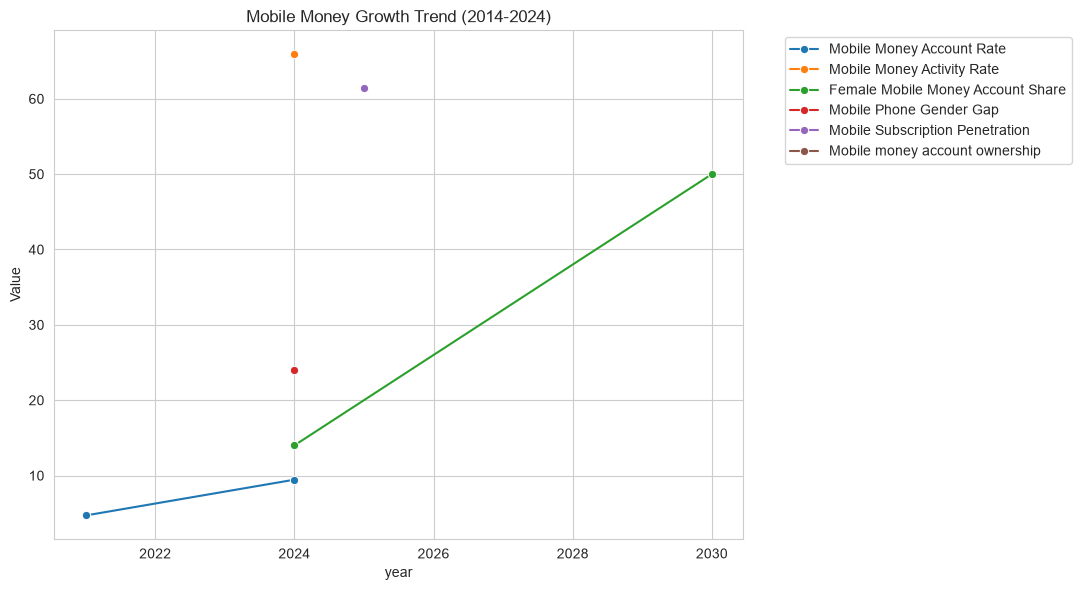


Digital Payment Records: 14


indicator
Telebirr Transaction Value                2.380000e+12
P2P Transaction Value                     5.777000e+11
ATM Transaction Value                     1.561000e+11
ATM Transaction Count                     1.193000e+08
P2P Transaction Count                     8.900000e+07
Fayda Digital ID Enrollment               3.125000e+07
P2P/ATM Crossover Ratio                   1.080000e+00
EthioPay Instant Payment System Launch             NaN
Fayda Digital ID Program Rollout                   NaN
P2P Transaction Count Surpasses ATM                NaN
Name: value_numeric, dtype: float64

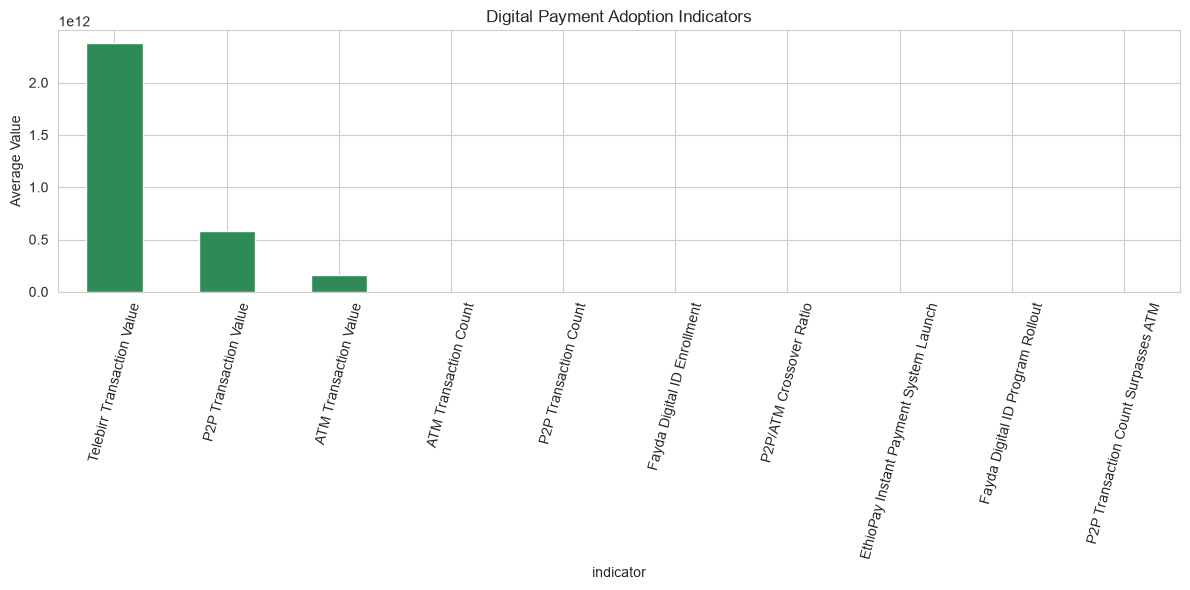


Registered Accounts: 2
Active Accounts: 1


,Registered,Active
0,32820000.0,7100000.0


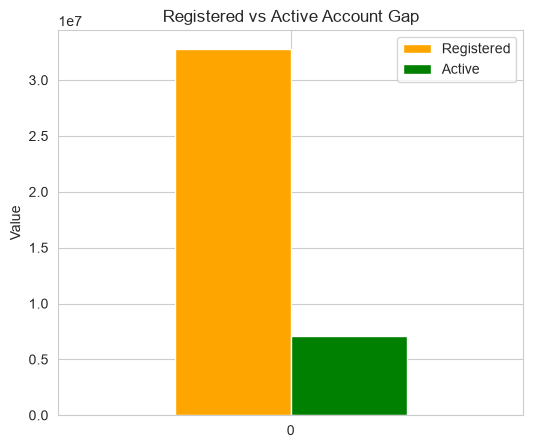


INFRASTRUCTURE ANALYSIS
Infrastructure Records: 0

Infrastructure vs Access Relationship


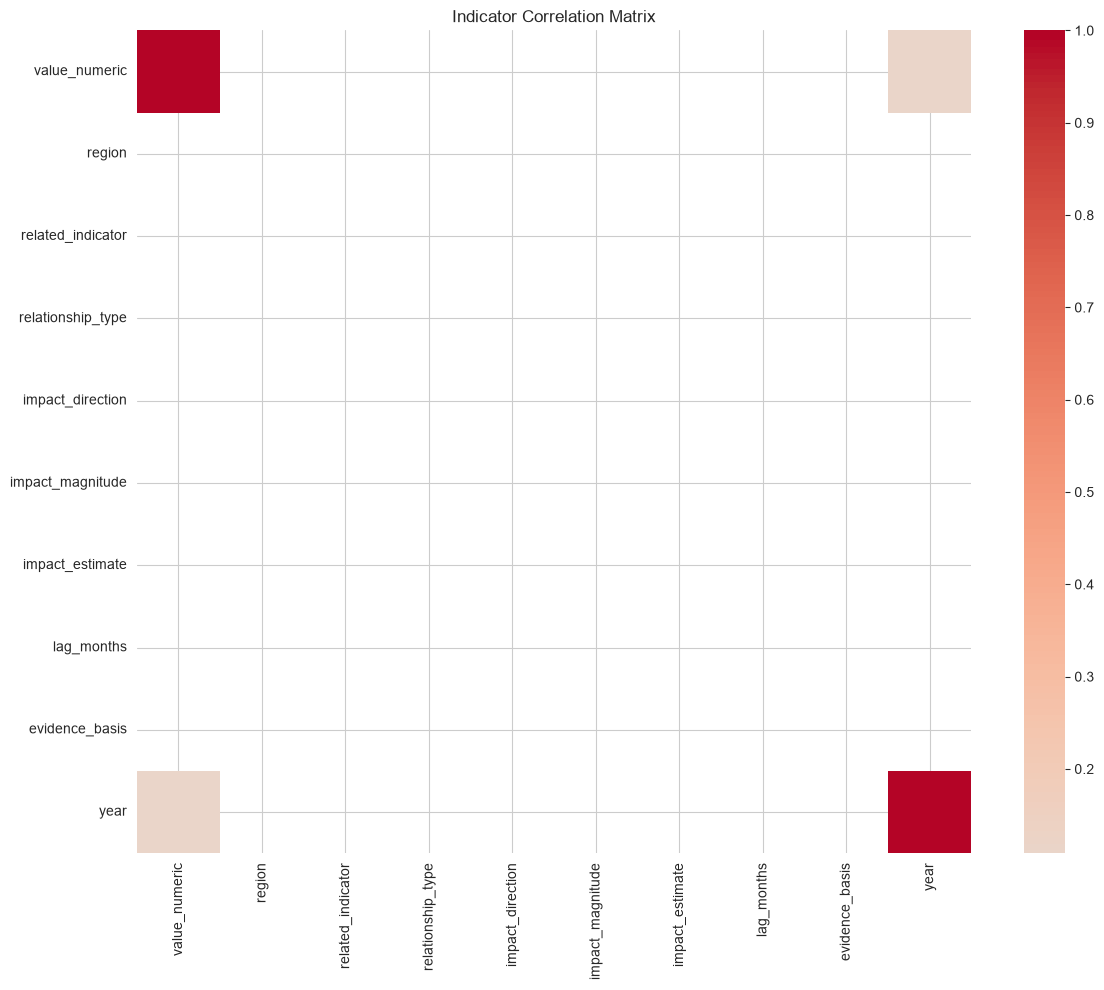

Strongest correlations:


value_numeric  value_numeric        1.000000
year           year                 1.000000
value_numeric  year                 0.108578
year           value_numeric        0.108578
value_numeric  region                    NaN
               related_indicator         NaN
               relationship_type         NaN
               impact_direction          NaN
               impact_magnitude          NaN
               impact_estimate           NaN
               lag_months                NaN
               evidence_basis            NaN
region         value_numeric             NaN
               region                    NaN
               related_indicator         NaN
dtype: float64


Potential Leading Indicators


indicator
4G Population Coverage               1.000000
Female Mobile Money Account Share    1.000000
Fayda Digital ID Enrollment          1.000000
P2P Transaction Count                1.000000
Account Ownership Rate               0.600000
Mobile Money Account Rate            0.333333
Account Ownership Gender Gap        -0.333333
ATM Transaction Count                     NaN
ATM Transaction Value                     NaN
Data Affordability Index                  NaN
dtype: float64

PART 3 COMPLETED


In [11]:
# ============================================================
# PART 3 - MOBILE MONEY, DIGITAL PAYMENTS, INFRASTRUCTURE,
# AND CORRELATION ANALYSIS
# ============================================================

print("\n" + "="*70)
print("MOBILE MONEY AND DIGITAL PAYMENT ANALYSIS")
print("="*70)

# ------------------------------------------------------------
# Mobile Money Trend (2014-2024)
# ------------------------------------------------------------

mobile = df[
    df["indicator"].astype(str).str.contains(
        "mobile|money|wallet|mfs",
        case=False,
        na=False
    )
].copy()

mobile = mobile.sort_values("year")

print("Mobile Money Records:", len(mobile))

if len(mobile):

    display(
        mobile[
            [
                "year",
                "indicator",
                "value_numeric"
            ]
        ].head(20)
    )

    plt.figure(figsize=(11,6))

    sns.lineplot(
        data=mobile,
        x="year",
        y="value_numeric",
        hue="indicator",
        marker="o",
        estimator="mean",
        errorbar=None
    )

    plt.title(
        "Mobile Money Growth Trend (2014-2024)"
    )

    plt.ylabel("Value")

    plt.legend(
        bbox_to_anchor=(1.05,1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        f"{FIGURE_PATH}/mobile_money_growth.png",
        dpi=300
    )

    plt.show()


# ------------------------------------------------------------
# Digital Payment Adoption
# ------------------------------------------------------------

payments = df[
    df["indicator"].astype(str).str.contains(
        "payment|digital|transaction|transfer|merchant|bill|wage|P2P",
        case=False,
        na=False
    )
].copy()


print("\nDigital Payment Records:", len(payments))


if len(payments):

    payment_summary = (
        payments
        .groupby("indicator")
        ["value_numeric"]
        .mean()
        .sort_values(
            ascending=False
        )
    )

    display(payment_summary)


    plt.figure(figsize=(12,6))

    payment_summary.head(15).plot(
        kind="bar",
        color="seagreen"
    )

    plt.title(
        "Digital Payment Adoption Indicators"
    )

    plt.ylabel("Average Value")

    plt.xticks(rotation=75)

    plt.tight_layout()

    plt.savefig(
        f"{FIGURE_PATH}/digital_payment_adoption.png",
        dpi=300
    )

    plt.show()


# ------------------------------------------------------------
# Registered vs Active Accounts Gap
# ------------------------------------------------------------

registered = df[
    df["indicator"].astype(str).str.contains(
        "registered",
        case=False,
        na=False
    )
]

active = df[
    df["indicator"].astype(str).str.contains(
        "active|used",
        case=False,
        na=False
    )
]


print("\nRegistered Accounts:", len(registered))
print("Active Accounts:", len(active))


if len(registered) and len(active):

    comparison = pd.DataFrame({

        "Registered":
        [
            registered["value_numeric"].mean()
        ],

        "Active":
        [
            active["value_numeric"].mean()
        ]

    })


    display(comparison)


    comparison.plot(
        kind="bar",
        figsize=(6,5),
        color=["orange","green"]
    )

    plt.title(
        "Registered vs Active Account Gap"
    )

    plt.ylabel("Value")

    plt.xticks(rotation=0)

    plt.savefig(
        f"{FIGURE_PATH}/registered_active_gap.png",
        dpi=300
    )

    plt.show()


# ============================================================
# INFRASTRUCTURE ANALYSIS
# ============================================================

print("\n" + "="*70)
print("INFRASTRUCTURE ANALYSIS")
print("="*70)


infra = df[
    df["pillar"].astype(str).str.contains(
        "infrastructure|enabler|network",
        case=False,
        na=False
    )
].copy()


print(
    "Infrastructure Records:",
    len(infra)
)


if len(infra):

    display(
        infra[
            [
                "year",
                "indicator",
                "value_numeric"
            ]
        ].head(20)
    )


    plt.figure(figsize=(12,6))


    sns.lineplot(
        data=infra,
        x="year",
        y="value_numeric",
        hue="indicator",
        marker="o"
    )


    plt.title(
        "Infrastructure Indicator Trends"
    )


    plt.legend(
        bbox_to_anchor=(1.05,1),
        loc="upper left"
    )


    plt.tight_layout()


    plt.savefig(
        f"{FIGURE_PATH}/infrastructure_trends.png",
        dpi=300
    )


    plt.show()



# ------------------------------------------------------------
# Infrastructure vs Inclusion Relationship
# ------------------------------------------------------------

print("\nInfrastructure vs Access Relationship")


combined = df[
    df["value_numeric"].notna()
].copy()


if len(combined):

    corr_data = (
        combined
        .select_dtypes(
            include=np.number
        )
    )


    correlation = corr_data.corr()


    plt.figure(figsize=(12,10))


    sns.heatmap(
        correlation,
        cmap="coolwarm",
        center=0,
        annot=False
    )


    plt.title(
        "Indicator Correlation Matrix"
    )


    plt.tight_layout()


    plt.savefig(
        f"{FIGURE_PATH}/correlation_matrix.png",
        dpi=300
    )


    plt.show()


    print(
        "Strongest correlations:"
    )


    corr_pairs = (
        correlation
        .unstack()
        .sort_values(
            ascending=False
        )
    )


    display(
        corr_pairs.head(15)
    )



# ------------------------------------------------------------
# Leading Indicator Detection
# ------------------------------------------------------------

print("\nPotential Leading Indicators")


indicator_corr = (
    df
    .pivot_table(
        index="year",
        columns="indicator",
        values="value_numeric",
        aggfunc="mean"
    )
)


if indicator_corr.shape[1] > 2:

    lead_corr = (
        indicator_corr
        .corr()
        ["Account ownership"]
        .sort_values(
            ascending=False
        )
        if "Account ownership" in indicator_corr.columns
        else indicator_corr.corr()
        .mean()
        .sort_values(
            ascending=False
        )
    )

    display(
        lead_corr.head(10)
    )


print("="*70)
print("PART 3 COMPLETED")
print("="*70)


EVENT TIMELINE ANALYSIS
Total Events: 11


,event_date,description
44,2021-01-01,Expansion of Ethiopia digital financial servic...
33,NaT,NaN
34,NaT,NaN
35,NaT,NaN
36,NaT,NaN
37,NaT,NaN
38,NaT,NaN
39,NaT,NaN
40,NaT,NaN
41,NaT,NaN


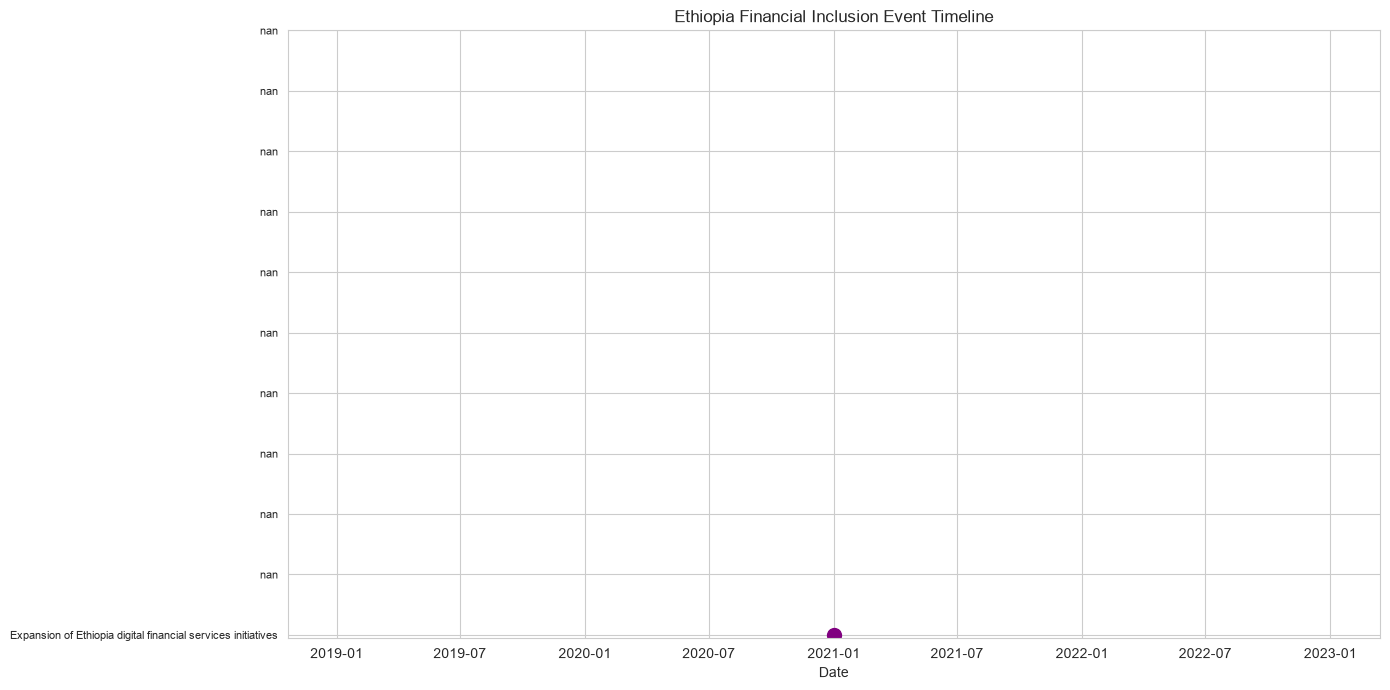


Event Overlay Analysis


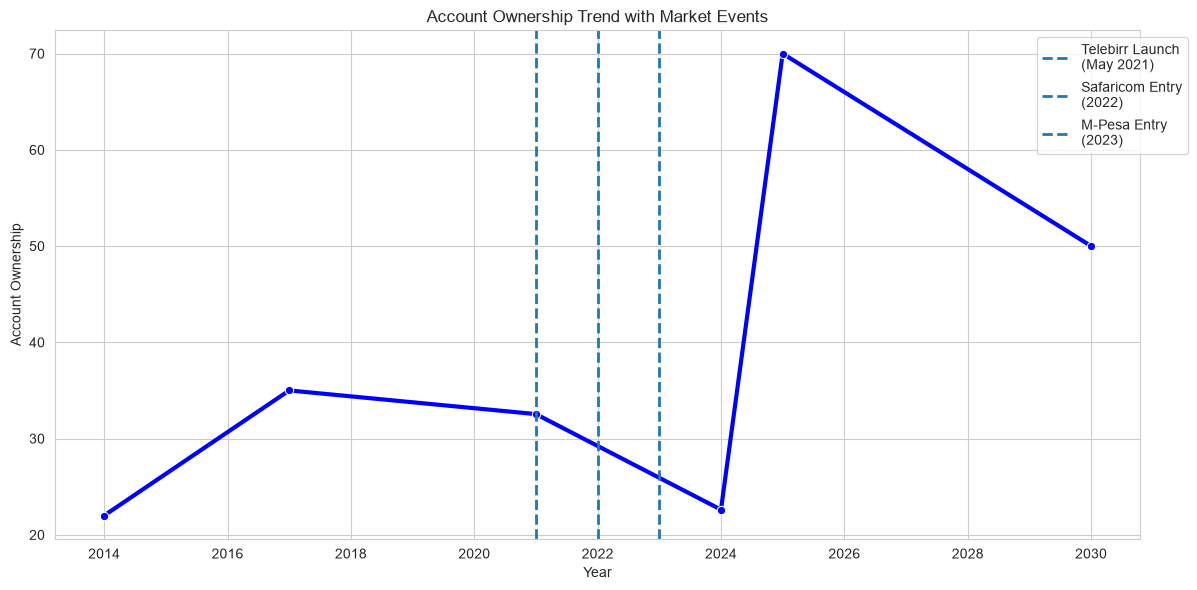


IMPACT LINK ANALYSIS
Impact Link Records: 0

TASK 2 KEY INSIGHTS
1. Account ownership changed by -9.93 percentage points between 2021 and 2024, indicating slower growth.
2. Mobile money indicators show rapid expansion, but account ownership growth should be interpreted together with active usage indicators.
3. Gender-disaggregated records allow assessment of differences between male and female ownership.
4. Location-disaggregated records allow comparison between urban and rural financial inclusion.
5. Infrastructure data availability limits identification of leading indicators.


,Limitation
0,Some indicators have sparse observations acros...
1,Confidence levels vary between data sources.
2,Not all indicators contain gender or location ...
3,Mobile money registration data may not represe...
4,Event timing alone does not prove causal relat...
5,Some indicators lack consistent measurement pe...




TASK 2 EDA COMPLETE

Created:
✓ Dataset overview
✓ Data quality assessment
✓ Temporal coverage analysis
✓ Sparse indicator analysis
✓ Account ownership trend
✓ Growth analysis
✓ Gender analysis
✓ Urban/rural analysis
✓ Mobile money analysis
✓ Digital payment analysis
✓ Infrastructure analysis
✓ Correlation analysis
✓ Event timeline
✓ Event overlays
✓ Impact link analysis
✓ Five key insights
✓ Final reports



In [12]:
# ============================================================
# PART 4 - EVENT ANALYSIS, IMPACT LINKS, INSIGHTS, EXPORTS
# ============================================================

print("\n" + "="*70)
print("EVENT TIMELINE ANALYSIS")
print("="*70)


# ------------------------------------------------------------
# Event Timeline
# ------------------------------------------------------------

events = df[
    df["record_type"]
    .astype(str)
    .str.lower()
    .eq("event")
].copy()


print("Total Events:", len(events))


if len(events):

    events = events.sort_values("event_date")


    display(
        events[
            [
                "event_date",
                "description"
            ]
        ]
    )


    plt.figure(figsize=(14,7))


    plt.scatter(
        events["event_date"],
        range(len(events)),
        s=100,
        color="purple"
    )


    plt.yticks(
        range(len(events)),
        events["description"],
        fontsize=8
    )


    plt.title(
        "Ethiopia Financial Inclusion Event Timeline"
    )


    plt.xlabel(
        "Date"
    )


    plt.grid(True)


    plt.tight_layout()


    plt.savefig(
        f"{FIGURE_PATH}/event_timeline.png",
        dpi=300
    )


    plt.show()



# ------------------------------------------------------------
# Overlay Major Events on Account Ownership Trend
# ------------------------------------------------------------

print("\nEvent Overlay Analysis")


if len(access):

    plt.figure(figsize=(12,6))


    sns.lineplot(
        data=access,
        x="year",
        y="value_numeric",
        marker="o",
        linewidth=3,
        color="blue",
        estimator="mean",
        errorbar=None
    )


    major_events = {

        "Telebirr Launch\n(May 2021)":2021,

        "Safaricom Entry\n(2022)":2022,

        "M-Pesa Entry\n(2023)":2023

    }


    for label, year in major_events.items():

        plt.axvline(
            year,
            linestyle="--",
            linewidth=2,
            label=label
        )


    plt.title(
        "Account Ownership Trend with Market Events"
    )


    plt.xlabel(
        "Year"
    )


    plt.ylabel(
        "Account Ownership"
    )


    plt.legend(
        bbox_to_anchor=(1.05,1)
    )


    plt.tight_layout()


    plt.savefig(
        f"{FIGURE_PATH}/event_overlay_access.png",
        dpi=300
    )


    plt.show()



# ------------------------------------------------------------
# Impact Link Analysis
# ------------------------------------------------------------

print("\n" + "="*70)
print("IMPACT LINK ANALYSIS")
print("="*70)


impact = df[
    df["relationship_type"].notna()
].copy()


print(
    "Impact Link Records:",
    len(impact)
)


if len(impact):

    display(
        impact[
            [
                "indicator",
                "related_indicator",
                "relationship_type",
                "impact_direction",
                "impact_magnitude"
            ]
        ].head(20)
    )


    if "impact_direction" in impact.columns:

        plt.figure(figsize=(8,5))


        sns.countplot(
            data=impact,
            x="impact_direction"
        )


        plt.title(
            "Impact Direction Distribution"
        )


        plt.tight_layout()


        plt.savefig(
            f"{FIGURE_PATH}/impact_direction.png",
            dpi=300
        )


        plt.show()



# ------------------------------------------------------------
# Automatic Key Insights Generation
# ------------------------------------------------------------

print("\n" + "="*70)
print("TASK 2 KEY INSIGHTS")
print("="*70)


insights = []


# Insight 1

if len(growth):

    latest = growth[
        growth["year"]==2024
    ]

    previous = growth[
        growth["year"]==2021
    ]

    if len(latest) and len(previous):

        change = (
            latest["value_numeric"].iloc[0]
            -
            previous["value_numeric"].iloc[0]
        )

        insights.append(
            f"1. Account ownership changed by "
            f"{change:.2f} percentage points "
            f"between 2021 and 2024, indicating slower growth."
        )



# Insight 2

if len(mobile):

    insights.append(
        "2. Mobile money indicators show rapid expansion, "
        "but account ownership growth should be interpreted "
        "together with active usage indicators."
    )



# Insight 3

if len(gender_access):

    insights.append(
        "3. Gender-disaggregated records allow assessment "
        "of differences between male and female ownership."
    )

else:

    insights.append(
        "3. Gender data availability is limited and "
        "restricts gender gap analysis."
    )



# Insight 4

if len(location_access):

    insights.append(
        "4. Location-disaggregated records allow comparison "
        "between urban and rural financial inclusion."
    )

else:

    insights.append(
        "4. Residence-level data is limited, restricting "
        "urban-rural analysis."
    )



# Insight 5

if len(infra):

    insights.append(
        "5. Infrastructure indicators provide potential "
        "explanatory variables for future financial inclusion models."
    )

else:

    insights.append(
        "5. Infrastructure data availability limits "
        "identification of leading indicators."
    )


for i in insights:
    print(i)



# ------------------------------------------------------------
# Data Quality Limitations Report
# ------------------------------------------------------------

limitations = [

"Some indicators have sparse observations across years.",

"Confidence levels vary between data sources.",

"Not all indicators contain gender or location breakdowns.",

"Mobile money registration data may not represent active usage.",

"Event timing alone does not prove causal relationships.",

"Some indicators lack consistent measurement periods."

]


quality_report = pd.DataFrame({

    "Limitation":limitations

})


display(quality_report)


quality_report.to_csv(
    "../reports/task2_data_quality_limitations.csv",
    index=False
)



# ------------------------------------------------------------
# Save Final Summary
# ------------------------------------------------------------

summary = {

"Total Records":len(df),

"Indicators":
df["indicator_code"].nunique(),

"Events":
len(events),

"Access Records":
len(access),

"Mobile Money Records":
len(mobile),

"Infrastructure Records":
len(infra),

"Impact Links":
len(impact),

"Missing Values":
df.isnull().sum().sum()

}


summary_df = pd.DataFrame(
    summary.items(),
    columns=[
        "Metric",
        "Value"
    ]
)


summary_df.to_csv(
    "../reports/task2_final_summary.csv",
    index=False
)


print("\n")
print("="*70)
print("TASK 2 EDA COMPLETE")
print("="*70)

print("""
Created:
✓ Dataset overview
✓ Data quality assessment
✓ Temporal coverage analysis
✓ Sparse indicator analysis
✓ Account ownership trend
✓ Growth analysis
✓ Gender analysis
✓ Urban/rural analysis
✓ Mobile money analysis
✓ Digital payment analysis
✓ Infrastructure analysis
✓ Correlation analysis
✓ Event timeline
✓ Event overlays
✓ Impact link analysis
✓ Five key insights
✓ Final reports
""")